In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import importlib
import dataset
from image_builder import *
from data_prepare import *
import data_fetch
from data_fetch import *
from data_fetch import _download_single, _read_mops_csv

importlib.reload(dataset)
importlib.reload(data_fetch)

ModuleNotFoundError: No module named 'numpy'

In [4]:
from dataset import *

START = "1993-01-01"
END = "2021-01-01"
TRAIN_END = "2001-01-01"
SAVE_DIR = "data"
Market = "US_1993_2020"
I = 5
R = 5

TICKERS, crsp_info = get_crsp_permno_universe(
    crsp_data_dir="us_stock_data",
    start=START,
    end=END,
    return_info=True,
)

print("permno 數量:", len(TICKERS))
display(crsp_info.head())


scan CRSP permnos: 100%|██████████| 28/28 [00:02<00:00,  9.46it/s]


permno 數量: 21285


,ticker,permno,first_year,last_year,rows
0,10001,10001,1993,2017,5666
1,10002,10002,1993,2013,3873
2,10003,10003,1993,1995,665
3,10009,10009,1993,2000,1347
4,10010,10010,1993,1995,670


In [ ]:
X_train, y_train, X_val, y_val, X_test, y_test, meta = build_research_dataset(
    tickers=TICKERS,
    start=START,
    end=END,
    I=I,
    R=R,
    train_end=TRAIN_END,
    save_dir=SAVE_DIR,
    Market=Market,
    price_source="crsp",
    crsp_data_dir="us_stock_data",
    checkpoint_every=1,
    resume=False,
    process_by="year",
    checkpoint_save_arrays=False,
    year_ticker_chunk_size=1000,
    max_workers = 2
)


Year-based CRSP build: pending years=[1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]

[I5/R5] build year: 1993


year 1993 tickers: 100%|██████████| 9037/9037 [14:09<00:00, 10.64it/s]


  done year 1993: 271456 images
  Checkpoint saved: 1 tickers done, 271456 images

[I5/R5] build year: 1994


year 1994 tickers: 100%|██████████| 9939/9939 [17:08<00:00,  9.66it/s]


  done year 1994: 303896 images
  Checkpoint saved: 2 tickers done, 575352 images

[I5/R5] build year: 1995


...

year 2004 tickers: 100%|██████████| 8121/8121 [16:44<00:00,  8.08it/s]   


  done year 2004: 298628 images
  Checkpoint saved: 12 tickers done, 3929675 images

[I5/R5] build year: 2005


year 2005 tickers: 100%|██████████| 7946/7946 [16:50<00:00,  7.87it/s]   


  done year 2005: 298977 images
  Checkpoint saved: 13 tickers done, 4228652 images

[I5/R5] build year: 2006


MemoryError: Unable to allocate 36.5 MiB for an array with shape (1, 4785997) and data type datetime64[ns]

In [4]:
dataset_dir = f"data/training_data/{Market}/I{I}R{R}S{R}"

X_train = np.load(f"{dataset_dir}/X_train.npy")
y_train = np.load(f"{dataset_dir}/y_train.npy")

X_val = np.load(f"{dataset_dir}/X_val.npy")
y_val = np.load(f"{dataset_dir}/y_val.npy")

X_test = np.load(f"{dataset_dir}/X_test.npy")
y_test = np.load(f"{dataset_dir}/y_test.npy")

meta = pd.read_csv(f"{dataset_dir}/meta.csv")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

display(meta.head())

X_train: (347, 32, 15)
y_train: (347,)
X_val: (149, 32, 15)
y_val: (149,)
X_test: (1404, 32, 15)
y_test: (1404,)


,ticker,start_date,date,label_end_date,label,ret,I,R,sample_step,price_source
0,10001,1993-01-14,1993-01-22,1993-02-09,0,-0.018170,5,5,5,crsp
1,10001,1993-01-27,1993-02-09,1993-02-24,0,-0.000320,5,5,5,crsp
2,10001,1993-02-10,1993-02-24,1993-03-10,1,0.056849,5,5,5,crsp
3,10001,1993-02-26,1993-03-10,1993-03-18,0,-0.026549,5,5,5,crsp
4,10001,1993-03-11,1993-03-18,1993-03-29,0,-0.052392,5,5,5,crsp


In [7]:
train_loader, val_loader, test_loader = dataset.make_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=128
)

# 3. 驗證一下載入的資料維度
sample_img, sample_label = next(iter(train_loader))
print(f"影像 Tensor 維度: {sample_img.shape}") 

影像 Tensor 維度: torch.Size([128, 1, 32, 15])


In [ ]:
import model
from model import *
importlib.reload(model)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
 
if I == 5:
    model = CNN_I5().to(device)
elif I == 20:
    model = CNN_I20().to(device)

# 定義損失函數和優化器
criterion = nn.CrossEntropyLoss()  # 交叉熵損失
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)  # Adam 優化器
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)

Using device: cuda


In [ ]:
# 儲存最佳驗證準確度
best_val_acc = 0.0
patience = 10  # 幾次沒進步就停止
trigger_times = 0

epochs = 50

# 用於儲存繪圖數據
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(epochs):
    # --- 訓練階段 ---
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # --- 驗證階段 ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # 計算平均值
    epoch_train_loss = train_loss / len(train_loader)
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = 100 * val_correct / val_total
    
    # 紀錄到 history
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    # 學習率調整
    scheduler.step(epoch_val_loss)

    # 儲存最佳模型
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), f'{Market}_best_model_I{I}R{R}.pth')
        trigger_times = 0  # Reset patience counter
    else:
        trigger_times += 1

    # 輸出訓練過程中的損失和準確度
    print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%')

    # 檢查是否達到早期停止條件
    if trigger_times >= patience:
        print("Early stopping: No improvement in validation accuracy.")
        break

Epoch [1/50] | Train Loss: 0.5192 | Val Loss: 0.6907 | Val Acc: 59.73%
Epoch [2/50] | Train Loss: 0.5191 | Val Loss: 0.6915 | Val Acc: 59.73%
Epoch [3/50] | Train Loss: 0.5115 | Val Loss: 0.6922 | Val Acc: 59.73%
Epoch [4/50] | Train Loss: 0.5221 | Val Loss: 0.6927 | Val Acc: 59.73%
Epoch [5/50] | Train Loss: 0.5135 | Val Loss: 0.6931 | Val Acc: 59.73%
Epoch [6/50] | Train Loss: 0.5382 | Val Loss: 0.6934 | Val Acc: 59.73%
Epoch [7/50] | Train Loss: 0.5563 | Val Loss: 0.6937 | Val Acc: 59.73%
Epoch [8/50] | Train Loss: 0.5424 | Val Loss: 0.6938 | Val Acc: 59.73%
Epoch [9/50] | Train Loss: 0.5400 | Val Loss: 0.6939 | Val Acc: 59.73%
Epoch [10/50] | Train Loss: 0.5044 | Val Loss: 0.6940 | Val Acc: 59.73%
Epoch [11/50] | Train Loss: 0.4983 | Val Loss: 0.6941 | Val Acc: 59.73%
Early stopping: No improvement in validation accuracy.


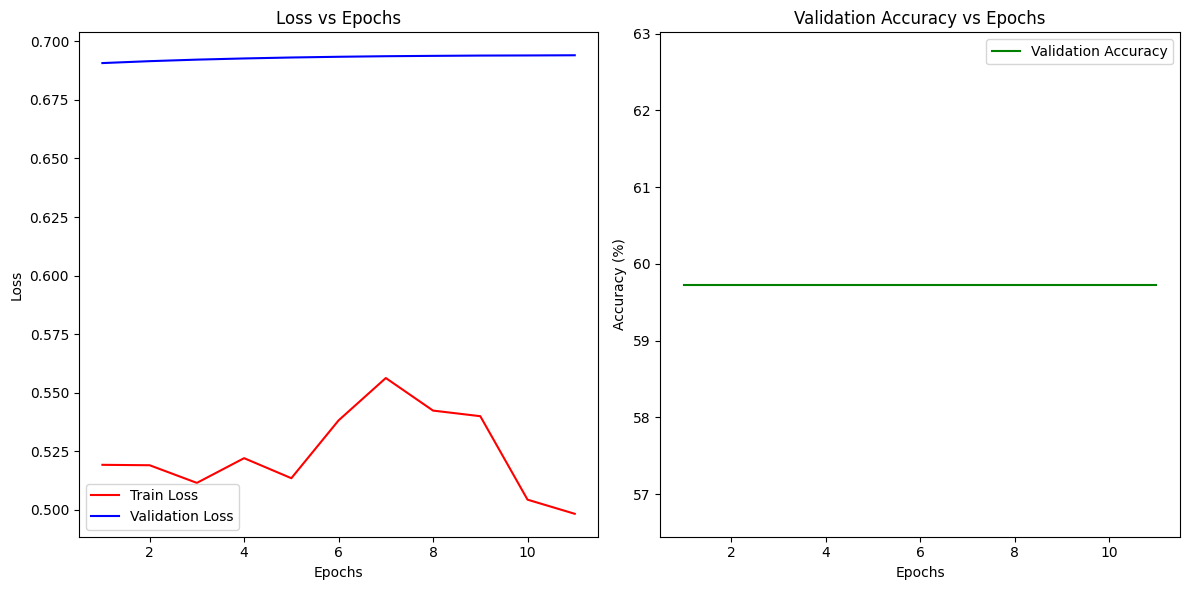

In [16]:
# --- 訓練過程圖 ---
# 繪製訓練過程中的損失和準確度變化圖
plt.figure(figsize=(12, 6))

# 損失圖
plt.subplot(1, 2, 1)
plt.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label="Train Loss", color="red")
plt.plot(range(1, len(history['val_loss']) + 1), history['val_loss'], label="Validation Loss", color="blue")
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# 準確度圖
plt.subplot(1, 2, 2)
plt.plot(range(1, len(history['val_acc']) + 1), history['val_acc'], label="Validation Accuracy", color="green")
plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()